# Rent per Square Metre Visualisation

Charts and maps of rent per sqm by local authority.


In [1]:
%reload_ext autoreload
%autoreload 2

In [ ]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
project_root = Path("..").resolve()
data_dir = project_root / "data"
plots_dir = project_root / "plots"

## Load Results


In [4]:
df = pd.read_csv(data_dir / "output" / "rent_per_sqm_by_la.csv")
print(f"Loaded {len(df)} local authorities")
df.head()

Loaded 316 local authorities


,la_code,la_name,region,rent_1bed,median_sqm_1bed,rent_per_sqm_1bed,rent_2bed,median_sqm_2bed,rent_per_sqm_2bed,rent_3bed,median_sqm_3bed,rent_per_sqm_3bed,rent_4bed_plus,median_sqm_4+bed,rent_per_sqm_4+bed,overall_rent_per_sqm,n_epc_obs,data_date
0,E09000033,Westminster,London,2583,42.0,61.500000,3356,68.0,49.352941,3959,92.0,43.032609,5564,141.0,39.460993,52.558385,20629.0,2025-11
1,E09000020,Kensington and Chelsea,London,2589,41.0,63.146341,3363,71.0,47.366197,3994,96.0,41.604167,5590,160.0,34.937500,51.745820,12960.0,2025-11
2,E09000007,Camden,London,1993,37.0,53.864865,2544,65.0,39.138462,2968,89.0,33.348315,3889,123.0,31.617886,43.793253,15247.0,2025-11
3,E09000019,Islington,London,2052,43.0,47.720930,2546,64.0,39.781250,2837,80.0,35.462500,4016,112.0,35.857143,42.106454,14015.0,2025-11
4,E09000013,Hammersmith and Fulham,London,1919,41.0,46.804878,2519,62.0,40.629032,2875,82.0,35.060976,4053,122.0,33.221311,40.873007,11853.0,2025-11


## Distribution of Rent per Sqm


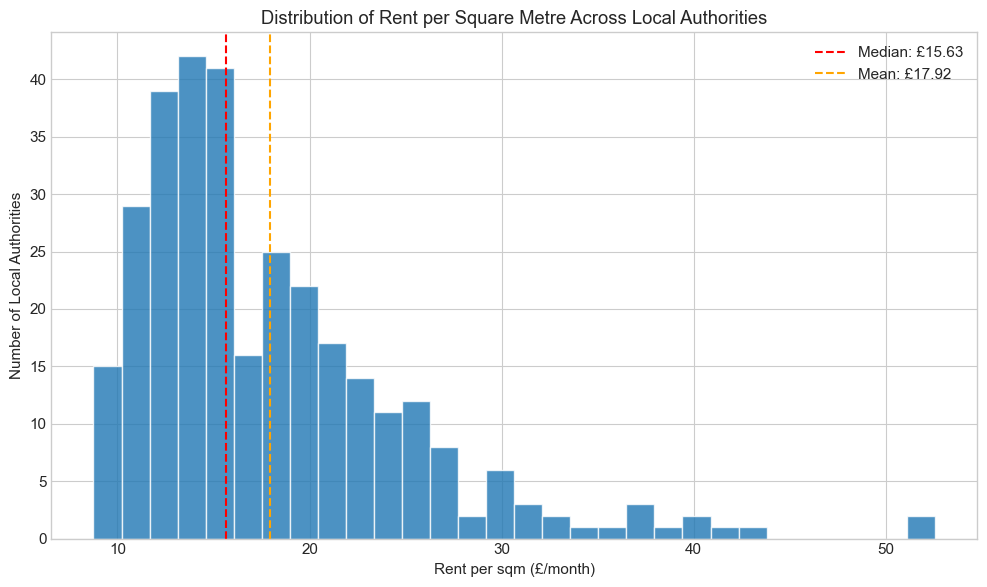

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df["overall_rent_per_sqm"].dropna(), bins=30, edgecolor="white", alpha=0.8)
ax.axvline(
    df["overall_rent_per_sqm"].median(),
    color="red",
    linestyle="--",
    label=f"Median: £{df['overall_rent_per_sqm'].median():.2f}",
)
ax.axvline(
    df["overall_rent_per_sqm"].mean(),
    color="orange",
    linestyle="--",
    label=f"Mean: £{df['overall_rent_per_sqm'].mean():.2f}",
)

ax.set_xlabel("Rent per sqm (£/month)")
ax.set_ylabel("Number of Local Authorities")
ax.set_title("Distribution of Rent per Square Metre Across Local Authorities")
ax.legend()

plt.tight_layout()
plt.savefig(plots_dir / "rent_psqm_distribution.png", dpi=150, transparent=True)
plt.show()

## Top and Bottom 20 Local Authorities


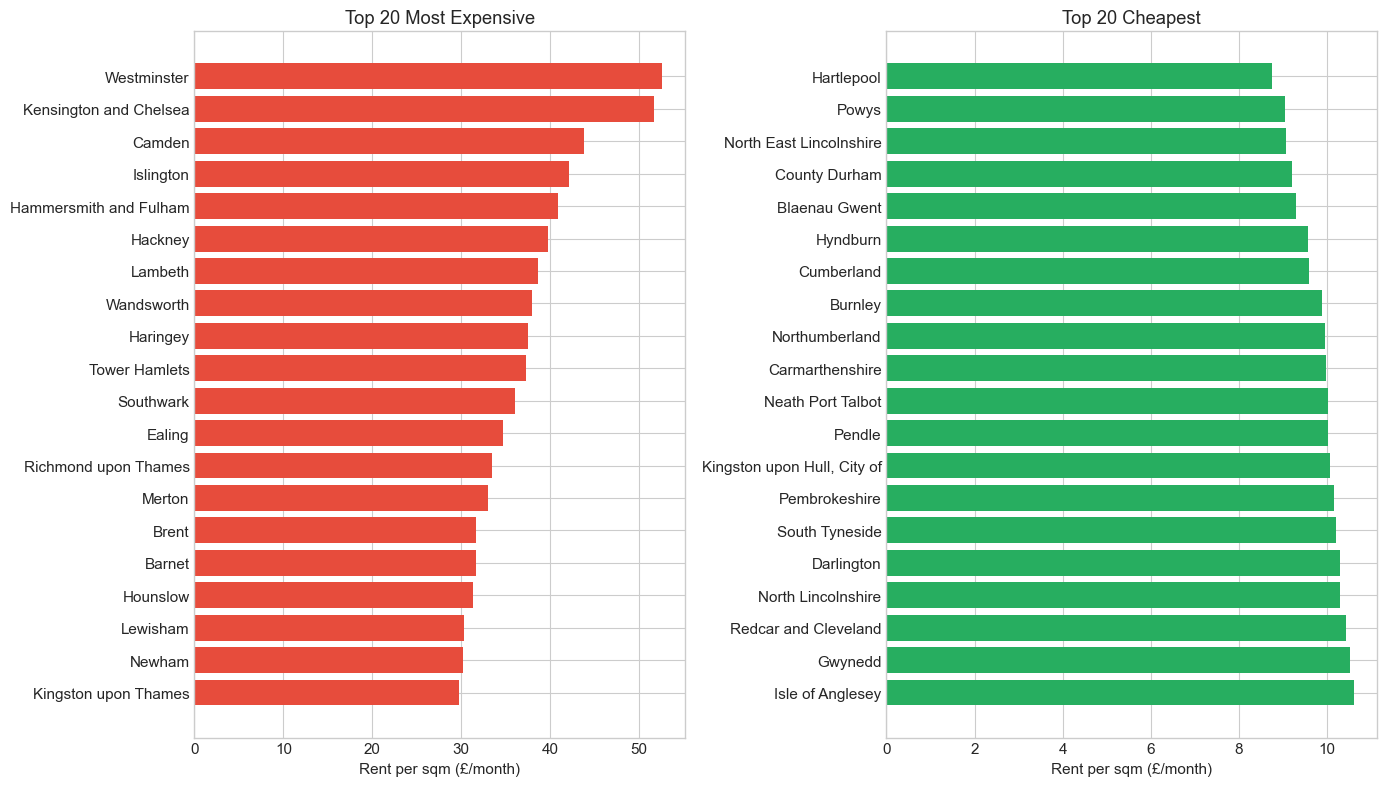

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top 20
top20 = df.nlargest(20, "overall_rent_per_sqm")
axes[0].barh(top20["la_name"], top20["overall_rent_per_sqm"], color="#e74c3c")
axes[0].set_xlabel("Rent per sqm (£/month)")
axes[0].set_title("Top 20 Most Expensive")
axes[0].invert_yaxis()

# Bottom 20
bottom20 = df.nsmallest(20, "overall_rent_per_sqm")
axes[1].barh(bottom20["la_name"], bottom20["overall_rent_per_sqm"], color="#27ae60")
axes[1].set_xlabel("Rent per sqm (£/month)")
axes[1].set_title("Top 20 Cheapest")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(plots_dir / "rent_psqm_top_bottom.png", dpi=150, transparent=True)
plt.show()

## Rent per Sqm by Bedroom Count


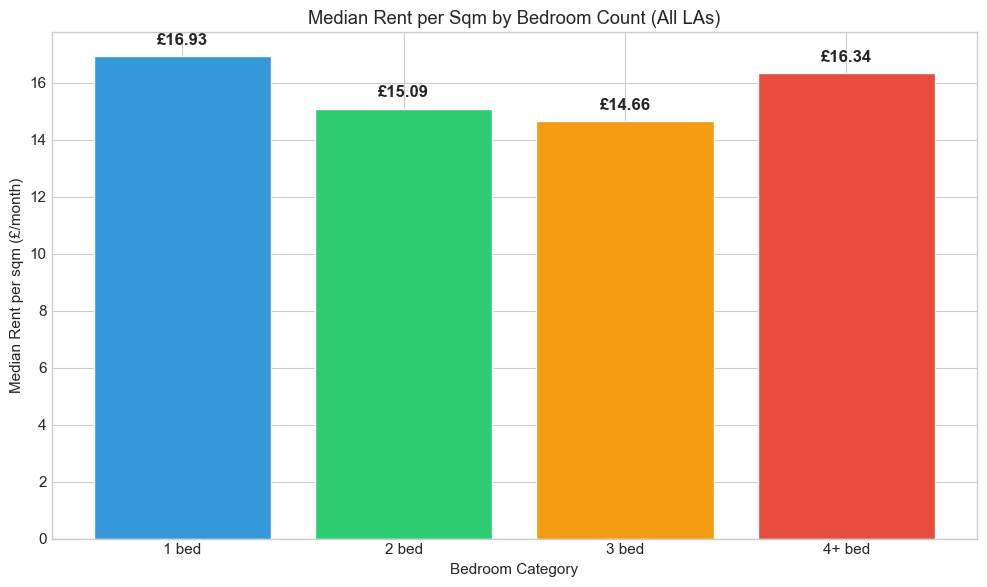

In [7]:
bedroom_cols = ["rent_per_sqm_1bed", "rent_per_sqm_2bed", "rent_per_sqm_3bed", "rent_per_sqm_4+bed"]
bedroom_labels = ["1 bed", "2 bed", "3 bed", "4+ bed"]

fig, ax = plt.subplots(figsize=(10, 6))

medians = [df[col].median() for col in bedroom_cols]
bars = ax.bar(bedroom_labels, medians, color=["#3498db", "#2ecc71", "#f39c12", "#e74c3c"], edgecolor="white")

for bar, median in zip(bars, medians):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"£{median:.2f}",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

ax.set_xlabel("Bedroom Category")
ax.set_ylabel("Median Rent per sqm (£/month)")
ax.set_title("Median Rent per Sqm by Bedroom Count (All LAs)")

plt.tight_layout()
plt.savefig(plots_dir / "rent_psqm_by_bedroom.png", dpi=150, transparent=True)
plt.show()

## Map: Rent per Sqm by Local Authority

Uses May 2024 LA boundaries from ONS ArcGIS FeatureServer.


In [8]:
# Load LA boundaries (May 2024 from ONS ArcGIS)
import sys

sys.path.insert(0, str(project_root / "src"))
from fetch_boundaries import fetch_lad_boundaries_2024

boundaries_path = data_dir / "raw" / "la_boundaries_2024.geojson"

if not boundaries_path.exists():
    print("Fetching 2024 LA boundaries from ONS...")
    geojson = fetch_lad_boundaries_2024(boundaries_path)
    gdf = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
else:
    gdf = gpd.read_file(boundaries_path)

print(f"Loaded {len(gdf)} LA boundaries")
gdf.head()

Loaded 361 LA boundaries


,LAD24CD,LAD24NM,geometry
0,E06000001,Hartlepool,"MULTIPOLYGON (((-1.22459 54.62418, -1.22457 54..."
1,E06000002,Middlesbrough,"MULTIPOLYGON (((-1.27712 54.54791, -1.2772 54...."
2,E06000003,Redcar and Cleveland,"MULTIPOLYGON (((-1.20098 54.57763, -1.20037 54..."
3,E06000004,Stockton-on-Tees,"MULTIPOLYGON (((-1.27493 54.55187, -1.27546 54..."
4,E06000005,Darlington,"POLYGON ((-1.43836 54.59508, -1.43807 54.59495..."


In [9]:
# Merge rent data with boundaries
la_code_col = "LAD24CD"  # Updated to 2024 codes

merged = gdf.merge(df, left_on=la_code_col, right_on="la_code", how="left")
print(f"Matched {merged['overall_rent_per_sqm'].notna().sum()} of {len(merged)} boundaries with rent data")

Matched 316 of 361 boundaries with rent data


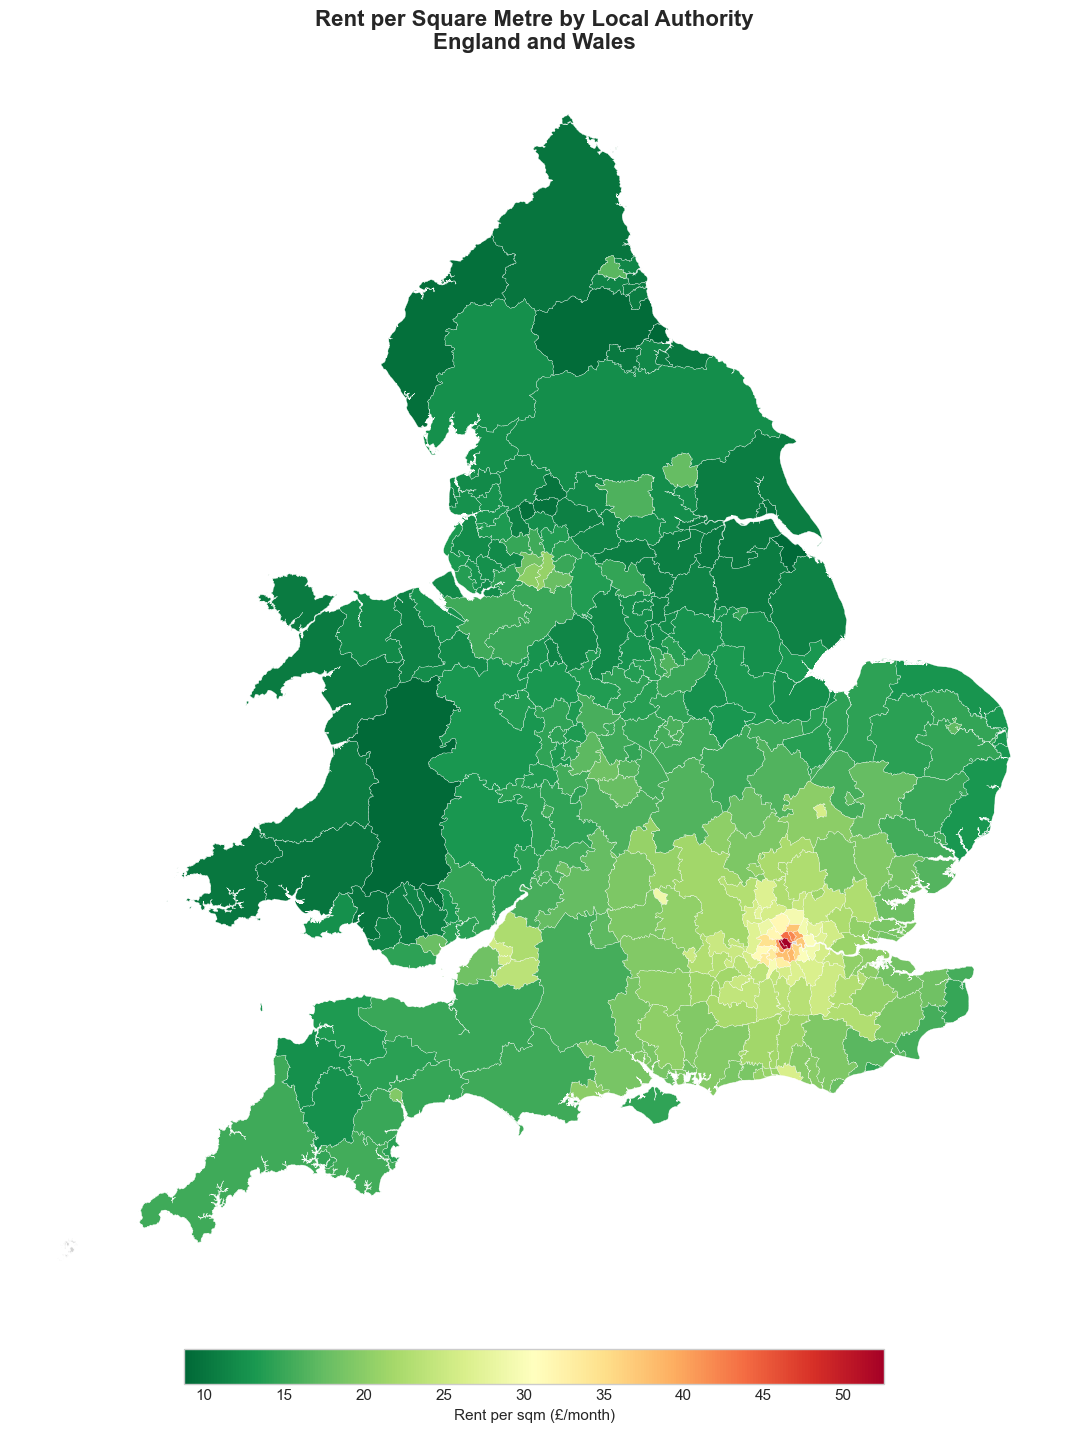

In [10]:
# Create the map
fig, ax = plt.subplots(figsize=(12, 16))

# Filter to England and Wales only (exclude Scotland and NI)
ew = merged[merged[la_code_col].str.startswith(("E", "W"))]

ew.plot(
    column="overall_rent_per_sqm",
    cmap="RdYlGn_r",  # Red=expensive, Green=cheap
    legend=True,
    legend_kwds={"label": "Rent per sqm (£/month)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.02},
    missing_kwds={"color": "lightgrey", "label": "No data"},
    ax=ax,
    edgecolor="white",
    linewidth=0.2,
)

ax.set_axis_off()
ax.set_title("Rent per Square Metre by Local Authority\nEngland and Wales", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(plots_dir / "rent_psqm_map.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

## London Zoom


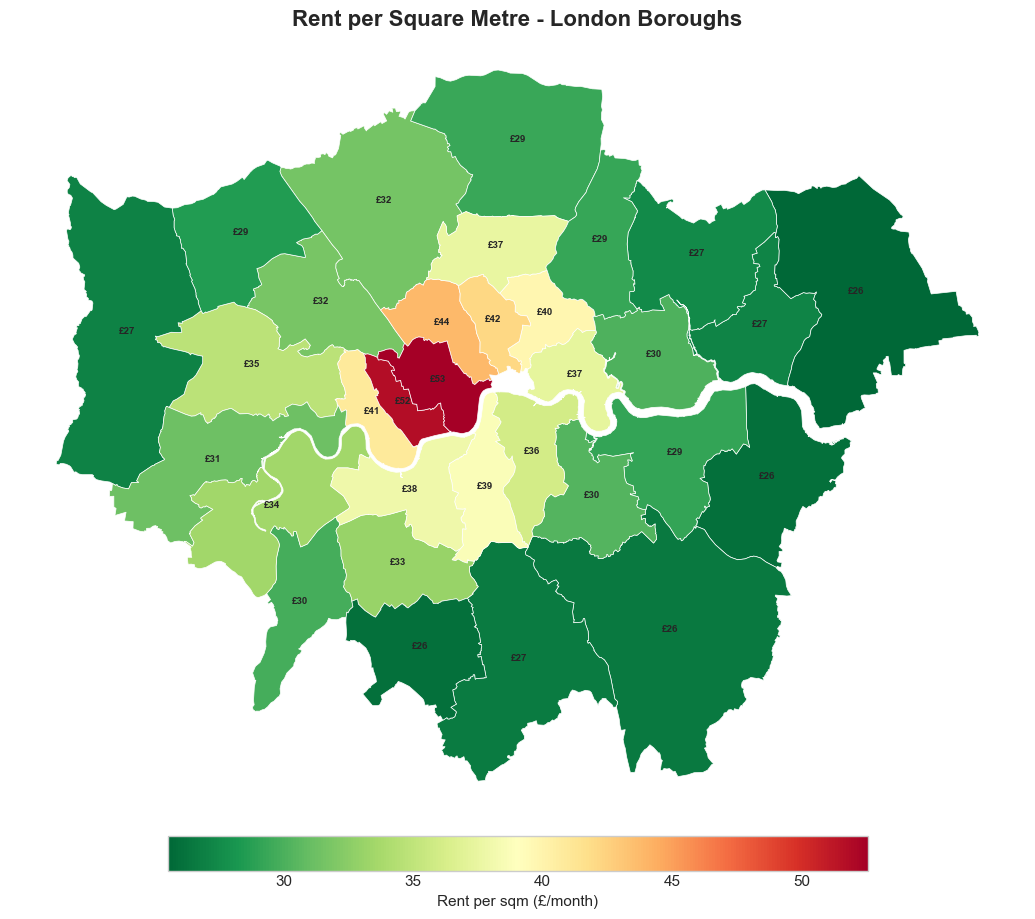

In [11]:
# London boroughs only (E09 codes)
london = merged[merged[la_code_col].str.startswith("E09")]

fig, ax = plt.subplots(figsize=(12, 10))

london.plot(
    column="overall_rent_per_sqm",
    cmap="RdYlGn_r",
    legend=True,
    legend_kwds={"label": "Rent per sqm (£/month)", "orientation": "horizontal", "shrink": 0.6, "pad": 0.02},
    ax=ax,
    edgecolor="white",
    linewidth=0.5,
)

# Add borough labels
for idx, row in london.iterrows():
    if pd.notna(row["overall_rent_per_sqm"]):
        centroid = row.geometry.centroid
        ax.annotate(
            f"£{row['overall_rent_per_sqm']:.0f}",
            xy=(centroid.x, centroid.y),
            ha="center",
            fontsize=7,
            fontweight="bold",
        )

ax.set_axis_off()
ax.set_title("Rent per Square Metre - London Boroughs", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.savefig(plots_dir / "rent_psqm_london.png", dpi=150, bbox_inches="tight", transparent=True)
plt.show()

## Summary Statistics


In [12]:
print("Summary Statistics")
print("=" * 40)
print(f"Number of LAs: {len(df)}")
print(f"Mean rent per sqm: £{df['overall_rent_per_sqm'].mean():.2f}/month")
print(f"Median rent per sqm: £{df['overall_rent_per_sqm'].median():.2f}/month")
print(f"Std dev: £{df['overall_rent_per_sqm'].std():.2f}")
print(f"Min: £{df['overall_rent_per_sqm'].min():.2f} ({df.loc[df['overall_rent_per_sqm'].idxmin(), 'la_name']})")
print(f"Max: £{df['overall_rent_per_sqm'].max():.2f} ({df.loc[df['overall_rent_per_sqm'].idxmax(), 'la_name']})")
print(f"\nRatio (max/min): {df['overall_rent_per_sqm'].max() / df['overall_rent_per_sqm'].min():.1f}x")

Summary Statistics
Number of LAs: 316
Mean rent per sqm: £17.92/month
Median rent per sqm: £15.63/month
Std dev: £7.10
Min: £8.75 (Hartlepool)
Max: £52.56 (Westminster)

Ratio (max/min): 6.0x
